The sinking of the Titanic is one of the most infamous shipwrecks in history. On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew. While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

Here I am building a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc). 
Logistic regression and KNN are the algorithms used to predict this dataset.

# Step 1: Importing the dataset and neccessary libraries¶

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df_train=pd.read_csv('../input/titanic/train.csv')
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 2: Getting to know the data¶

In [3]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Let's see what some of the columns mean:

survival: 0 = No, 1 = Yes

pclass: Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd

sibsp: number of siblings / spouses aboard the Titanic

parch: number of parents / children aboard the Titanic

ticket: Ticket number

fare: Passenger fare, the money paid for a journey on public transport.

cabin: Cabin number

embarked, Port of Embarkation: C = Cherbourg, Q = Queenstown, S = Southampton

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df_train.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


# Step 3: Dealing with the missing data

Now let's see how many missing data do we have?

In [6]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We can see from the information that some info are not really necassary to keep, because they have no impact on the survival. Things like ticket number:

In [7]:
df_train.drop(['Ticket'], axis=1, inplace=True)

In [8]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

percentage = missing_percent(df_train)
percentage

Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64

(array([0, 1, 2]),
 [Text(0, 0, 'Embarked'), Text(1, 0, 'Age'), Text(2, 0, 'Cabin')])

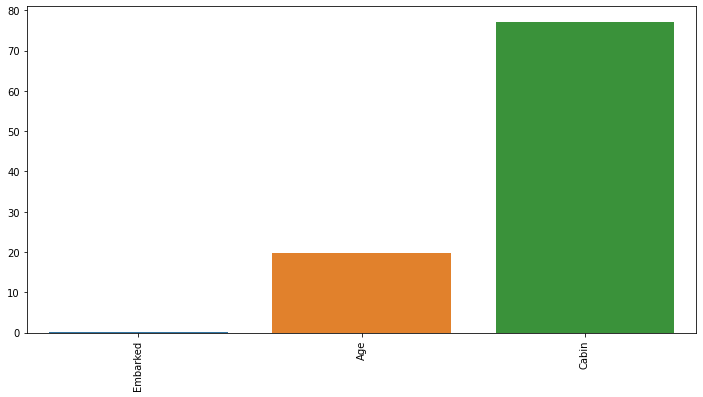

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(x=percentage.index, y=percentage)
plt.xticks(rotation=90)

And now let's look at the ones with less than 1%.

In [10]:
percentage[percentage<1]

Embarked    0.224467
dtype: float64

## Embarked

only 0.22 % is a missing data, so let's just fill it with the mode of the embarks:

In [11]:
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

missing_percent(df_train)

Age      19.865320
Cabin    77.104377
dtype: float64

## Cabin

With 77 % missing information maybe it is best to drop the column which does not give us that much of an information:

In [12]:
df_train.drop(['Cabin'], axis=1, inplace=True)

missing_percent(df_train)

Age    19.86532
dtype: float64

## Age

With 19% of missing data, we can just fill it with the median of the age:

In [13]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

missing_percent(df_train)

Series([], dtype: float64)

Finally there is no missing data!

# Step 4: Exploratory data analysis

Let't see how many people survived in titanic:

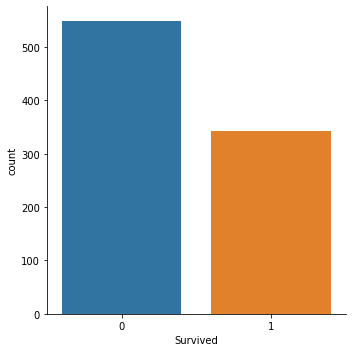

In [14]:
sns.catplot(x='Survived', data=df_train, kind="count")

Unfortunately many more people did not survive. Let's look at the factors: gender, age, pclass, fare, embarked, title and being alone.

## Gender

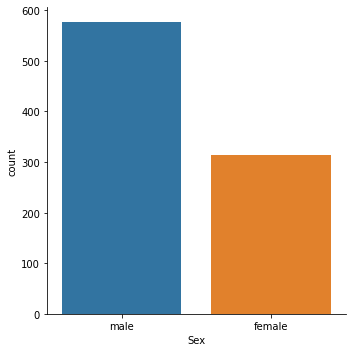

In [15]:
sns.catplot(x='Sex', data=df_train, kind="count")

We can see that more men were on the deck.

## Age

<AxesSubplot:xlabel='Age', ylabel='Count'>

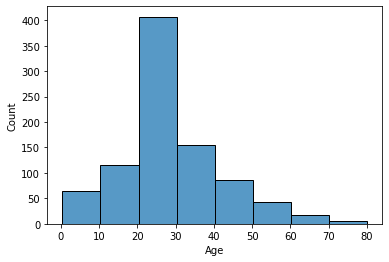

In [16]:
sns.histplot(df_train['Age'], bins= 8)

Most of the people aged between 20-30. Let's look at the age condidering the gender:

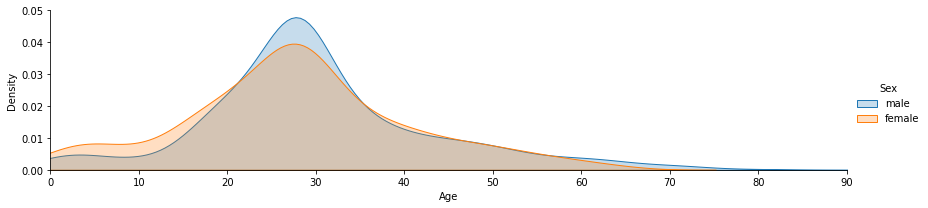

In [17]:
fig = sns.FacetGrid(df_train, hue="Sex",aspect=4)
fig.map(sns.kdeplot,'Age',shade= True)
fig.set(xlim=(0,90))
fig.add_legend()

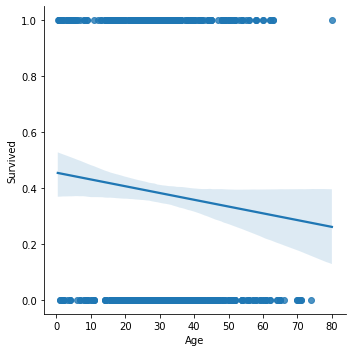

In [18]:
sns.lmplot(x='Age',y='Survived',data=df_train)

We can see that the younger people had more change of survival. Is is true for both men and women?

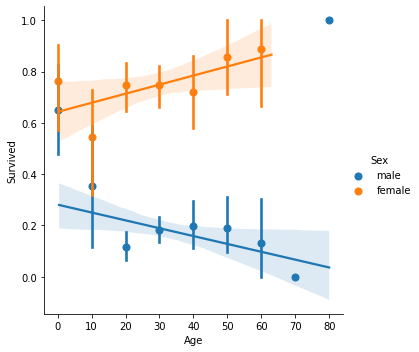

In [19]:
sns.lmplot(x='Age',y='Survived',data=df_train, hue='Sex', x_bins=[0,10,20,30,40,50,60,70,80,90])

It seems that being an old female gave the passengers more chance of survival than being an old male!
Were there any children on titanic? Let's see if we can make a seperate group for children. If we say people under 16 are children:

In [20]:
def adult(passenger):
    age, sex = passenger
    if age < 16:
        return 'child'
    else:
        return sex
    
df_train['Person'] = df_train[['Age','Sex']].apply(adult, axis=1)

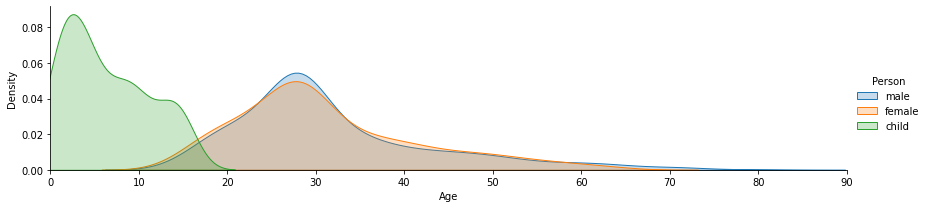

In [21]:
fig = sns.FacetGrid(df_train, hue="Person",aspect=4)
fig.map(sns.kdeplot,'Age',shade= True)
fig.set(xlim=(0,90))
fig.add_legend()

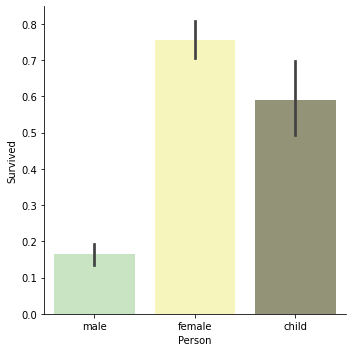

In [22]:
sns.catplot(x='Person',y='Survived',kind='bar', data=df_train, palette ='Set3_d')

Well! We can see that they must have the "female and children go first" policy. 

## Pclass

Pclass is the ticket class and it can be 1 = 1st, 2 = 2nd, 3 = 3rd.

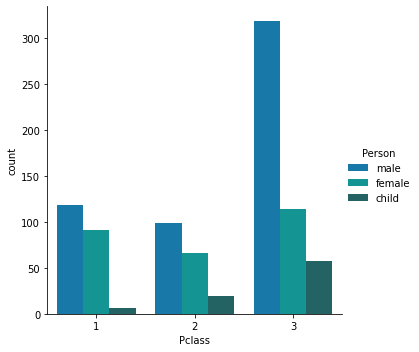

In [23]:
sns.catplot(x="Pclass", data=df_train, hue="Person", kind="count", palette='winter_d')

We can see that there are more children in third class and not so many in first class.

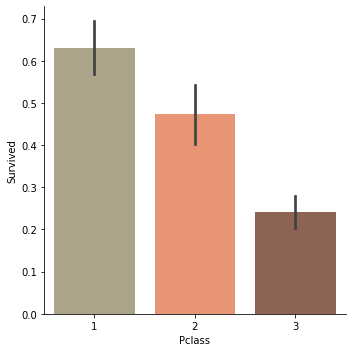

In [24]:
sns.catplot(x='Pclass',y='Survived',kind='bar', data=df_train, palette = 'Set2_d')

It seems that survival rate for the first class was more.

## Fare

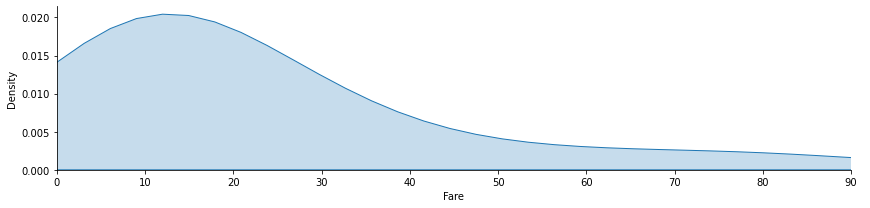

In [25]:
fig = sns.FacetGrid(df_train,aspect=4)
fig.map(sns.kdeplot,'Fare',shade= True)
fig.set(xlim=(0,90))
fig.add_legend()

We see most of the people paid 5-15 dollars for their ticket. Let's see if this is related to the pclass and rate of survival:

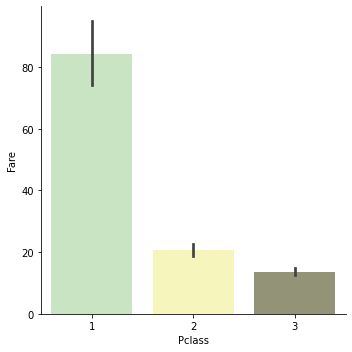

In [26]:
sns.catplot(x='Pclass',y='Fare',kind='bar', data=df_train, palette ='Set3_d')

Of course as we expected people paid way more for the first class. But let's see if paying more helped them to survive more?

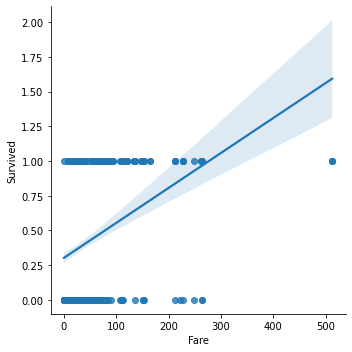

In [27]:
sns.lmplot(x='Fare',y='Survived',data=df_train)

Yes! If you'd pay more, it was more likely you could've survived.

## Embarked

Where did the passengers come from? If we look at the project on Kaggle we see that these stand for Cherbourg, Queenstown, Southhampton.

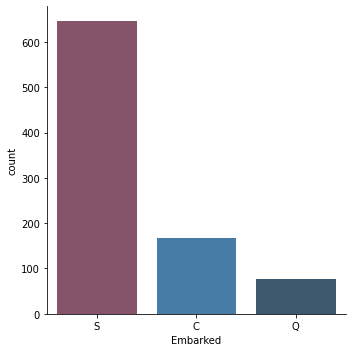

In [28]:
sns.catplot(x="Embarked", data=df_train, kind="count", palette='Set1_d')

We see a lot of people came from Southhampton. Let's see if they were in different Pclasses:

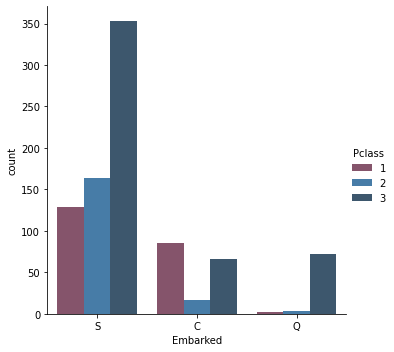

In [29]:
sns.catplot(x="Embarked", data=df_train, kind="count", hue='Pclass', palette='Set1_d')

Almost all people from Queenstown were in third class.

## Title

Let's see what practical information we can get from the names:

In [30]:
df_train['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

We see a family name, title. and name. So maybe we can use these titles for some analyzing:

In [31]:
df_train['Title'] = df_train.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

In [32]:
df_train['Title'].value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64

Title Miss and Mme (mademoiselle) was used for an unmarried woman. Title Mrs or Mme (madame) was used for a married woman. Title Master is an honorific for boys and young men. The other titles are rare, so let's just put them on one group:

In [33]:
df_train['Title'] = df_train['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Don', 'Ms'], 'Rare')
df_train['Title'] = df_train['Title'].replace('Mlle', 'Miss')
df_train['Title'] = df_train['Title'].replace('Mme', 'Mrs')

In [34]:
df_train['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

Let's see if the title is corrolated with surviving:

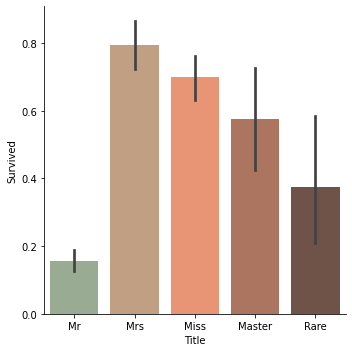

In [35]:
sns.catplot(x='Title',y='Survived',kind='bar', data=df_train, palette ='Set2_d')

We can clearly see that titles Mrs, Miss and Master survived more than others, specially from Mr. Surely this has something to do with the age or sex.

## Being alone or not

If someone had no family they are considered alone. Let's make a column named family first:

In [36]:
df_train['Alone'] = (df_train['SibSp'] + df_train['Parch'] == 0)

def Alone_or_not (passenger):
    if passenger == True:
        return "Alone"
    if passenger == False:
        return "With Family"

df_train['Family'] = df_train['Alone'].apply(Alone_or_not)

In [37]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Person,Title,Alone,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,male,Mr,False,With Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,female,Mrs,False,With Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,female,Miss,True,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,female,Mrs,False,With Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,male,Mr,True,Alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,male,Rare,True,Alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,female,Miss,True,Alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,23.4500,S,female,Miss,False,With Family
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,male,Mr,True,Alone


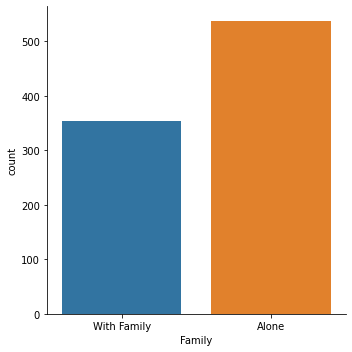

In [38]:
sns.catplot(x='Family', data=df_train, kind="count")

So it seems that most of the people were alone on the titanic.

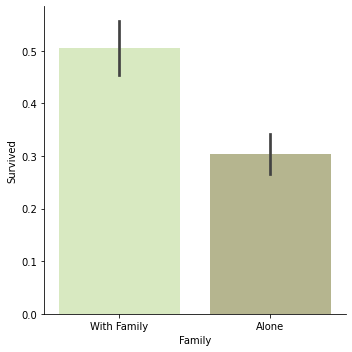

In [39]:
sns.catplot(x='Family',y='Survived',kind='bar', data=df_train, palette ='Set3_d')

It seems that people with family survived more than alone people!

# Step 5: Importing the test dataset and do the changes

## Import

In [40]:
df_test=pd.read_csv('../input/titanic/test.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Let's remember from Id=892 to the end belongs to the test dataset.

## Apply changes

We have changed things on the train dataset that we need to do also on test dataset. Also for changing them to dummy variables we need them to be one dataset. Then we will split them and build a model:

In [41]:
df_test.drop(['Ticket'], axis=1, inplace=True)
df_test.drop(['Cabin'], axis=1, inplace=True)

In [42]:
df_test['Title'] = df_test.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Don', 'Dona', 'Ms'], 'Rare')
df_test['Title'] = df_test['Title'].replace('Mlle', 'Miss')
df_test['Title'] = df_test['Title'].replace('Mme', 'Mrs')

In [43]:
df_test.drop(['Name'], axis=1, inplace=True)

In [44]:
df_test['Alone'] = (df_test['SibSp'] + df_test['Parch'] == 0)

def Alone_or_not (passenger):
    if passenger == True:
        return "Alone"
    if passenger == False:
        return "With Family"

df_test['Family'] = df_test['Alone'].apply(Alone_or_not)

In [45]:
df_test.drop(['SibSp', 'Parch', 'Alone' ], axis=1, inplace=True)

## Dealing with missing values

In [46]:
df_test.isnull().sum()

PassengerId     0
Pclass          0
Sex             0
Age            86
Fare            1
Embarked        0
Title           0
Family          0
dtype: int64

We fill the age with median age of train dataset:

In [47]:
df_test['Age'] = df_test['Age'].fillna(df_train['Age'].median())
df_test.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
Fare           1
Embarked       0
Title          0
Family         0
dtype: int64

We fill the fair according to its pclass (in train dataset):

In [48]:
df_train.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [49]:
df_test['Fare']=df_test.groupby('Pclass')['Fare'].transform(lambda val: val.fillna(val.mean()))
df_test.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
Title          0
Family         0
dtype: int64

# Step 6: Merging the test and train dataset

Let's take another look at both train and test dataset:

In [50]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Person,Title,Alone,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,male,Mr,False,With Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,female,Mrs,False,With Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,female,Miss,True,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,female,Mrs,False,With Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,male,Mr,True,Alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,male,Rare,True,Alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,female,Miss,True,Alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,23.4500,S,female,Miss,False,With Family
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,male,Mr,True,Alone


We save the survived people in y and drop other columns which are not necessary to keep:

In [51]:
y = df_train['Survived']
df_train.drop(['Person', 'SibSp', 'Parch', 'Name', 'Alone', 'Survived' ], axis=1, inplace=True)

In [52]:
df_train

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,Family
0,1,3,male,22.0,7.2500,S,Mr,With Family
1,2,1,female,38.0,71.2833,C,Mrs,With Family
2,3,3,female,26.0,7.9250,S,Miss,Alone
3,4,1,female,35.0,53.1000,S,Mrs,With Family
4,5,3,male,35.0,8.0500,S,Mr,Alone
...,...,...,...,...,...,...,...,...
886,887,2,male,27.0,13.0000,S,Rare,Alone
887,888,1,female,19.0,30.0000,S,Miss,Alone
888,889,3,female,28.0,23.4500,S,Miss,With Family
889,890,1,male,26.0,30.0000,C,Mr,Alone


In [53]:
df_test

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,Family
0,892,3,male,34.5,7.8292,Q,Mr,Alone
1,893,3,female,47.0,7.0000,S,Mrs,With Family
2,894,2,male,62.0,9.6875,Q,Mr,Alone
3,895,3,male,27.0,8.6625,S,Mr,Alone
4,896,3,female,22.0,12.2875,S,Mrs,With Family
...,...,...,...,...,...,...,...,...
413,1305,3,male,28.0,8.0500,S,Mr,Alone
414,1306,1,female,39.0,108.9000,C,Rare,Alone
415,1307,3,male,38.5,7.2500,S,Mr,Alone
416,1308,3,male,28.0,8.0500,S,Mr,Alone


In [54]:
df = pd.concat([df_train , df_test], axis=0)
df.index = np.arange(1, len(df) + 1)
df

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,Family
1,1,3,male,22.0,7.2500,S,Mr,With Family
2,2,1,female,38.0,71.2833,C,Mrs,With Family
3,3,3,female,26.0,7.9250,S,Miss,Alone
4,4,1,female,35.0,53.1000,S,Mrs,With Family
5,5,3,male,35.0,8.0500,S,Mr,Alone
...,...,...,...,...,...,...,...,...
1305,1305,3,male,28.0,8.0500,S,Mr,Alone
1306,1306,1,female,39.0,108.9000,C,Rare,Alone
1307,1307,3,male,38.5,7.2500,S,Mr,Alone
1308,1308,3,male,28.0,8.0500,S,Mr,Alone


Now we can drop the passenger Id as it is similar to the index:

In [55]:
df.drop('PassengerId', axis=1, inplace=True)
df

,Pclass,Sex,Age,Fare,Embarked,Title,Family
1,3,male,22.0,7.2500,S,Mr,With Family
2,1,female,38.0,71.2833,C,Mrs,With Family
3,3,female,26.0,7.9250,S,Miss,Alone
4,1,female,35.0,53.1000,S,Mrs,With Family
5,3,male,35.0,8.0500,S,Mr,Alone
...,...,...,...,...,...,...,...
1305,3,male,28.0,8.0500,S,Mr,Alone
1306,1,female,39.0,108.9000,C,Rare,Alone
1307,3,male,38.5,7.2500,S,Mr,Alone
1308,3,male,28.0,8.0500,S,Mr,Alone


# Step 7: Dealing with the categorical data

In [56]:
df_num= df.select_dtypes(exclude='object')
df_obj= df.select_dtypes(include='object')

In [57]:
df_obj= pd.get_dummies(df_obj, drop_first=True)

In [58]:
df_obj

,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Family_With Family
1,1,0,1,0,1,0,0,1
2,0,0,0,0,0,1,0,1
3,0,0,1,1,0,0,0,0
4,0,0,1,0,0,1,0,1
5,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...
1305,1,0,1,0,1,0,0,0
1306,0,0,0,0,0,0,1,0
1307,1,0,1,0,1,0,0,0
1308,1,0,1,0,1,0,0,0


In [59]:
df_obj_train = df_obj.iloc[:891, :]
df_obj_test = df_obj.iloc[891:, :]

# Step 8: Dealing with the numerical values

In [60]:
df_num_train = df_num.iloc[:891, :]
df_num_test = df_num.iloc[891:, :]

In [61]:
names = df_num_train.columns

from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(df_num_train)
df_num_train= scaler.transform(df_num_train)
df_num_test= scaler.transform(df_num_test)

df_num_train = pd.DataFrame(df_num_train, columns= names)
df_num_train.index = np.arange(1, len(df_num_train) + 1)

df_num_test = pd.DataFrame(df_num_test, columns= names)
df_num_test.index = np.arange(892, 892 + len(df_num_test))

In [62]:
df_train = pd.concat([df_num_train, df_obj_train], axis=1)
df_test = pd.concat([df_num_test, df_obj_test], axis=1)
df_test

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Family_With Family
892,0.827377,0.394887,-0.490783,1,1,0,0,1,0,0,0
893,0.827377,1.355510,-0.507479,0,0,1,0,0,1,0,1
894,-0.369365,2.508257,-0.453367,1,1,0,0,1,0,0,0
895,0.827377,-0.181487,-0.474005,1,0,1,0,1,0,0,0
896,0.827377,-0.565736,-0.401017,0,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1305,0.827377,-0.104637,-0.486337,1,0,1,0,1,0,0,0
1306,-1.566107,0.740711,1.544246,0,0,0,0,0,0,1,0
1307,0.827377,0.702286,-0.502445,1,0,1,0,1,0,0,0
1308,0.827377,-0.104637,-0.486337,1,0,1,0,1,0,0,0


# Step 9-A: Building a logistic regression model

In [63]:
from sklearn.linear_model import LogisticRegression
log_model= LogisticRegression()
log_model.fit(df_train, y)

LogisticRegression()

In [64]:
log_model.coef_

array([[-0.96798455, -0.35680376,  0.03796682, -1.15416919, -0.06163961,
        -0.55414127, -0.4018625 , -1.89341945,  0.36856846, -1.36483752,
        -0.5019001 ]])

# Step 10-A: Predicting the test data

In [65]:
y_pred_lr= log_model.predict(df_test)
y_pred_lr

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

# Step 11-A: Evaluating the model

In [66]:
y_test=pd.read_csv('../input/titanic/gender_submission.csv')
y_test_e = y_test['Survived'].to_numpy()
y_test_e

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix

In [68]:
accuracy_score(y_test_e, y_pred_lr)

0.9425837320574163

In [69]:
confusion_matrix(y_test_e, y_pred_lr)

array([[250,  16],
       [  8, 144]])

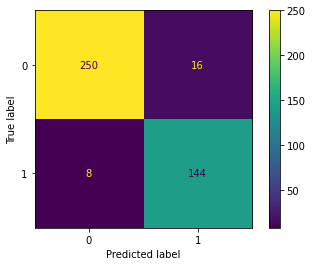

In [70]:
plot_confusion_matrix(log_model, df_test , y_test_e)

In [71]:
print(classification_report(y_test_e, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       266
           1       0.90      0.95      0.92       152

    accuracy                           0.94       418
   macro avg       0.93      0.94      0.94       418
weighted avg       0.94      0.94      0.94       418



# Step 12-A: Evaluating Curves and AUC

In [72]:
from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve

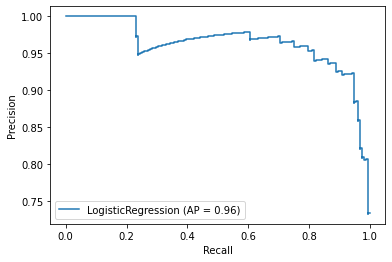

In [73]:
plot_precision_recall_curve(log_model, df_test, y_test_e)

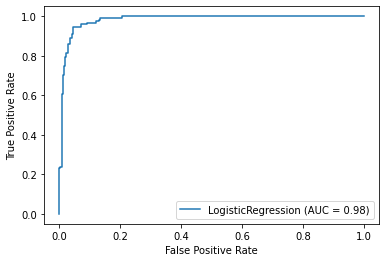

In [74]:
plot_roc_curve(log_model, df_test, y_test_e)

# Step 9-B: Building a KNN model

If you want to know why we chose 18 for n_neighbors, look at section 12_B.

In [75]:
from sklearn.neighbors import KNeighborsClassifier
knn_model= KNeighborsClassifier(n_neighbors=18)
knn_model.fit(df_train, y)

KNeighborsClassifier(n_neighbors=18)

In [76]:
log_model.coef_

array([[-0.96798455, -0.35680376,  0.03796682, -1.15416919, -0.06163961,
        -0.55414127, -0.4018625 , -1.89341945,  0.36856846, -1.36483752,
        -0.5019001 ]])

# Step 10-B: Predicting the test data

In [77]:
y_pred_knn= knn_model.predict(df_test)

# Step 11-B: Evaluating the model

In [78]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [79]:
accuracy_score(y_test_e, y_pred_knn)

0.9138755980861244

In [80]:
confusion_matrix(y_test_e, y_pred_knn)

array([[255,  11],
       [ 25, 127]])

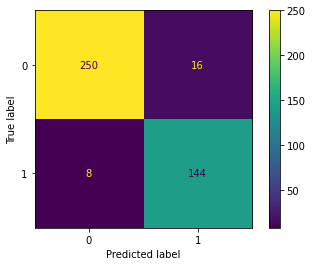

In [81]:
plot_confusion_matrix(log_model, df_test , y_test_e)

In [82]:
print(classification_report(y_test_e, y_pred_knn))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       266
           1       0.92      0.84      0.88       152

    accuracy                           0.91       418
   macro avg       0.92      0.90      0.90       418
weighted avg       0.91      0.91      0.91       418



# Step 12-B: Elbow Method for Choosing Reasonable K Values

In [83]:
test_error_rate= []


for k in range (1, 30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(df_train, y)
    
    y_pred_test = knn_model.predict(df_test)
    
    test_error=1- accuracy_score(y_test_e, y_pred_test)
    test_error_rate.append(test_error)

In [84]:
test_error_rate

[0.22009569377990434,
 0.16028708133971292,
 0.18899521531100483,
 0.1578947368421053,
 0.12200956937799046,
 0.11004784688995217,
 0.10526315789473684,
 0.11244019138755978,
 0.09808612440191389,
 0.10287081339712922,
 0.11004784688995217,
 0.10765550239234445,
 0.11244019138755978,
 0.09808612440191389,
 0.09808612440191389,
 0.09569377990430628,
 0.09090909090909094,
 0.0861244019138756,
 0.0861244019138756,
 0.1004784688995215,
 0.10287081339712922,
 0.1004784688995215,
 0.11004784688995217,
 0.11244019138755978,
 0.10765550239234445,
 0.10765550239234445,
 0.10287081339712922,
 0.10765550239234445,
 0.11004784688995217]

Text(0.5, 0, 'K Value')

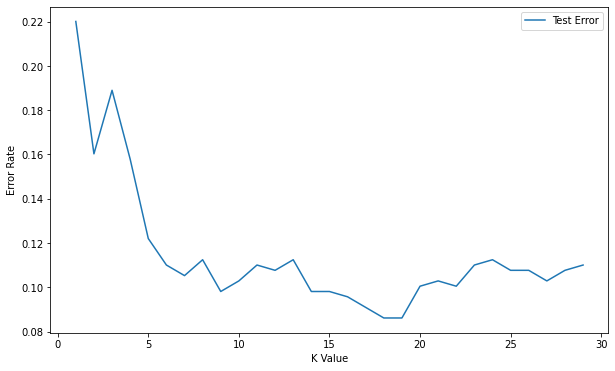

In [85]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), test_error_rate, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')

We see that k=18 and 19 are the best.

# Step 13: Submitting the predicted data

By evaluating the models, we can see the logistic regression has a higher accuracy rate. So we choose y_pred_lr for submitting the data:

In [86]:
submission = pd.DataFrame()
submission['PassengerId'] = df_test.index
submission['Survived'] = y_pred_lr
submission.to_csv('my-submission.csv',index=False)